# Day 3 hands-on: reweighting and transformers

The transformer part is adapted from the Vision Transformer tutorial of the Heidelberg ViT lecture, rewritten for sets of particles.

In this session we
1. use a classifier to **reweight** one distribution into another, with the likelihood ratio trick from Day 1:
$$w(x) = \frac{P(B)}{P(A)} \, \frac{C(x)}{1-C(x)} = \frac{p(x|A)}{p(x|B)} \; ;$$
2. build a small **transformer** from scratch and use it on events made of several particles, where the question is which particles belong together.

**Colab:** everything runs on the CPU, each training takes well under a minute. Run the cells from top to bottom with `Shift+Enter`.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
rng = np.random.default_rng(42)

## 1) Reweighting: from a flat distribution to two moons

Yesterday we *generated* two moons from noise. Today we take a different route: we start from events that are easy to produce, uniformly distributed in a box, and give each of them a weight such that the weighted events look like the two moons. Nothing is moved, the events just count more or less.

The two samples are $A$ = two moons (label 1) and $B$ = uniform (label 0). We train the classifier from Day 1 to separate them.

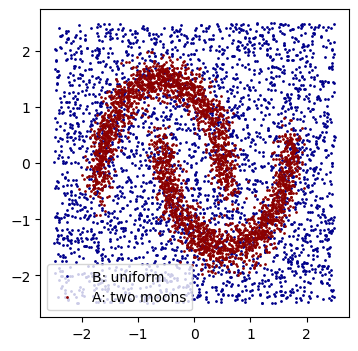

In [2]:
def get_moons(n, noise=0.1, seed=0):
    x, _ = make_moons(n_samples=n, noise=noise, random_state=seed)
    x = (x - np.array([0.5, 0.25])) / np.array([0.87, 0.5])     # roughly mean 0, width 1, as on Day 2
    return torch.tensor(x, dtype=torch.float32)


def get_uniform(n, box):
    return (torch.rand(n, 2) * 2 - 1) * box                     # uniform in [-box, box]^2


class DeepClassifier(nn.Module):                                # the network from Day 1
    def __init__(self, n_hidden=64):
        super().__init__()
        self.layer1 = nn.Linear(2, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.sigmoid(self.layer3(x))
        return x.squeeze(-1)


def train_classifier(model, x, y, n_epochs, lr=1e-3):
    loader = DataLoader(TensorDataset(x, y), batch_size=256, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        for x_batch, y_batch in loader:
            loss = nn.BCELoss()(model(x_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    print(f"final loss {loss.item():.3f}")


x_moons = get_moons(10000)
plt.figure(figsize=(5, 4))
x_uniform = get_uniform(3000, 2.5)
plt.plot(x_uniform[:, 0], x_uniform[:, 1], ".", color="darkblue", ms=2, label="B: uniform")
plt.plot(x_moons[:3000, 0], x_moons[:3000, 1], ".", color="darkred", ms=2, label="A: two moons")
plt.legend()
plt.gca().set_aspect("equal")
plt.show()

**Task 1:** complete `compute_weights`: turn the classifier output $C$ on the uniform events into weights that reweight them to the two moons. Then run the experiment and look at the plots: the weights over the plane, the weighted uniform events against the moons, and the one-dimensional distributions.

final loss 0.405
effective number of events: 2435 out of 10000


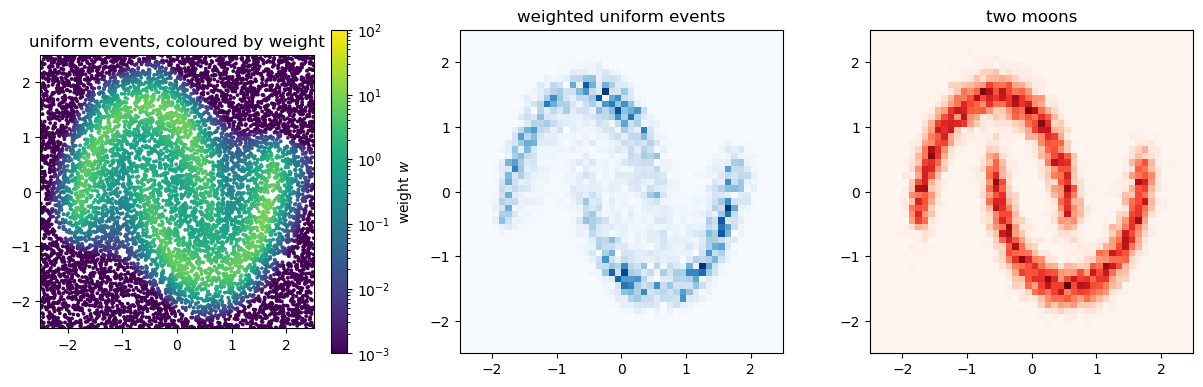

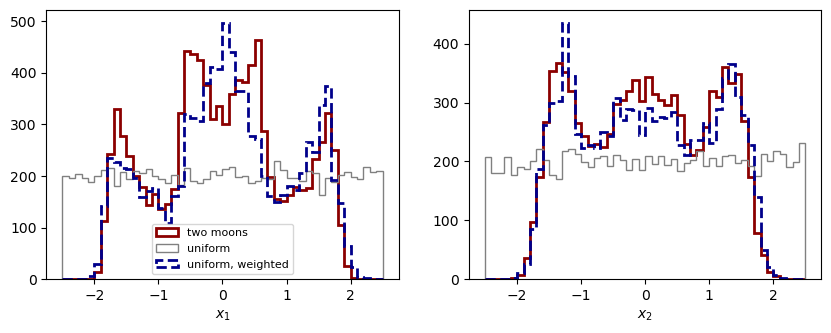

In [3]:
def compute_weights(C, n_A, n_B):
    ########################################
    ### Compute the weights here ###
    w = n_B / n_A * C / (1 - C)          # P(B)/P(A) * C/(1-C) = p(x|A)/p(x|B)
    ########################################
    return w


def reweighting_experiment(box, n_epochs=30, n=10000):
    x_A = get_moons(n, seed=1)
    x_B = get_uniform(n, box)
    x = torch.cat([x_A, x_B])
    y = torch.cat([torch.ones(n), torch.zeros(n)])
    model = DeepClassifier()
    train_classifier(model, x, y, n_epochs)

    # fresh uniform events to be reweighted
    x_B_new = get_uniform(n, box)
    with torch.no_grad():
        C = model(x_B_new).clamp(1e-6, 1 - 1e-6)
    w = compute_weights(C, n_A=n, n_B=n)
    n_eff = w.sum()**2 / (w**2).sum()
    print(f"effective number of events: {n_eff:.0f} out of {n}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    sc = axes[0].scatter(x_B_new[:, 0], x_B_new[:, 1], c=w, s=3, cmap="viridis", norm=LogNorm(1e-3, 1e2))
    fig.colorbar(sc, ax=axes[0], label="weight $w$")
    axes[0].set_title("uniform events, coloured by weight")
    edges = np.linspace(-2.5, 2.5, 51)
    axes[1].hist2d(x_B_new[:, 0].numpy(), x_B_new[:, 1].numpy(), bins=edges, weights=w.numpy(), cmap="Blues")
    axes[1].set_title("weighted uniform events")
    axes[2].hist2d(x_A[:, 0].numpy(), x_A[:, 1].numpy(), bins=edges, cmap="Reds")
    axes[2].set_title("two moons")
    for ax in axes:
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_aspect("equal")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for i, ax in enumerate(axes):
        ax.hist(x_A[:, i], edges, histtype="step", color="darkred", lw=2, label="two moons")
        ax.hist(x_B_new[:, i], edges, histtype="step", color="grey", label="uniform")
        ax.hist(x_B_new[:, i], edges, weights=w, histtype="step", color="darkblue", lw=2, ls="--", label="uniform, weighted")
        ax.set_xlabel(f"$x_{i + 1}$")
    axes[0].legend(fontsize=8)
    plt.show()
    return w


########################################
### Modify the box size here ###
box = 2.5
########################################
w = reweighting_experiment(box)

**Solution notes:** both samples have the same size, so the prior factor is one and $w = C/(1-C)$. The weighted uniform events reproduce the moons in two dimensions and in both projections. Only a small fraction of the uniform events sit on the moons, so most weights are tiny, and the effective number of events is much smaller than the number of events we started with: reweighting costs statistics.

**Task 2:** shrink the box to `box = 1.0`, so that the uniform events no longer cover the whole two-moons distribution, and run the experiment again. What happens, and why can no classifier fix this?

final loss 0.300
effective number of events: 3433 out of 10000


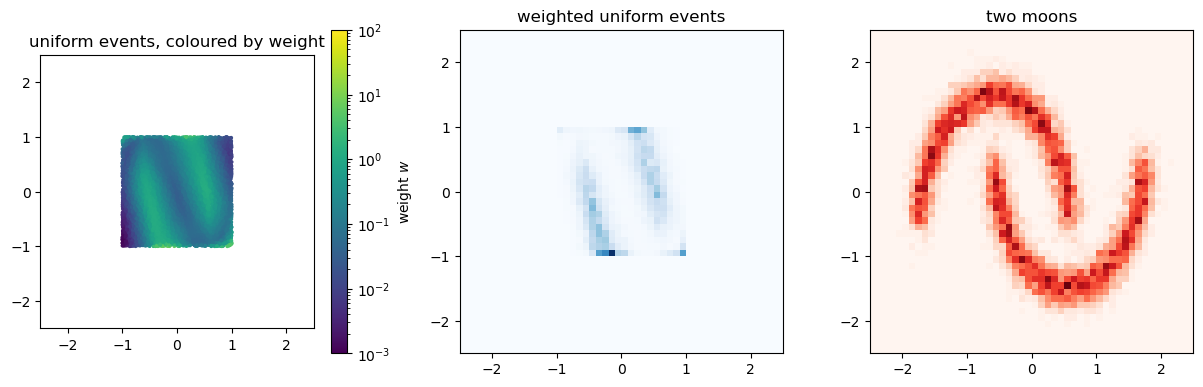

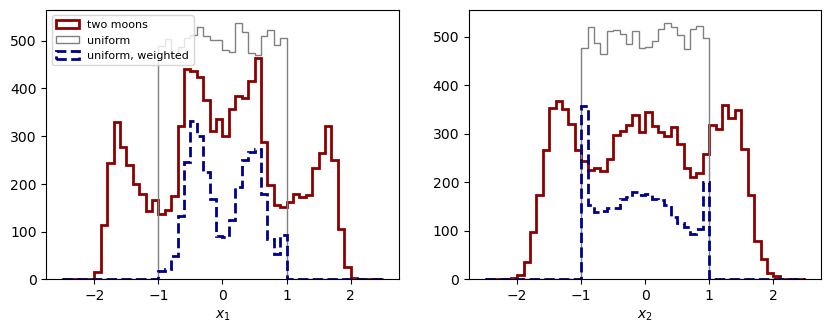

In [4]:
########################################
### Modify the box size here ###
box = 1.0
########################################
w_small = reweighting_experiment(box)

**Solution notes:** the parts of the moons outside the box are simply missing. Reweighting can only change how much an existing event counts; where $p(x|B) = 0$ there are no events to reweight, and the likelihood ratio $p(x|A)/p(x|B)$ is not even defined. The classifier also sees perfectly separable samples outside the box, so its output there saturates, but there are no uniform events to apply it to. In practice the sample we reweight must cover the target everywhere, and we should always check the weight distribution.

## 2) Transformers on sets of particles

### The dataset
Each event consists of 8 particles, each described by its momentum vector $\vec p = (p_x, p_y, p_z)$.
* In **background** events, all 8 momenta are random.
* In **signal** events, a heavy particle decayed at rest into two of them. Momentum conservation makes these two back-to-back with equal size, $\vec p_2 \approx -\vec p_1$, up to some detector smearing. The other 6 particles are random.

The particles come in a random order, so we do not know which two particles form the pair. To find a signal event, the network has to compare the particles with each other.

events: torch.Size([20000, 8, 3])   (events, particles, features)


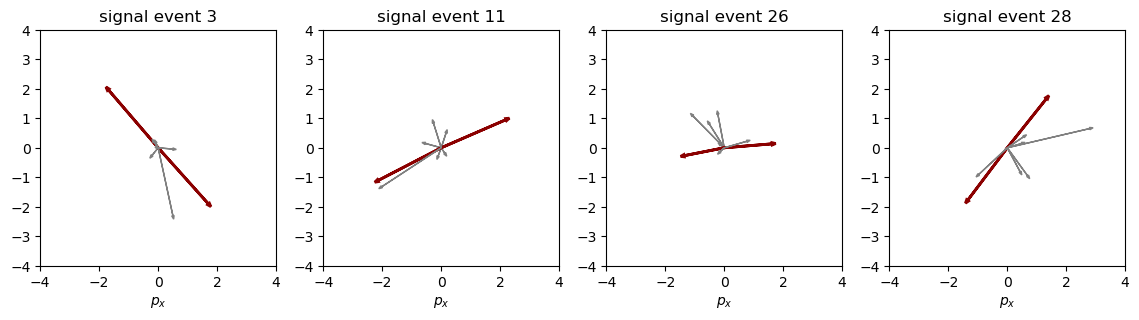

In [5]:
def make_events(n, n_particles=8, smear=0.05):
    y = (rng.random(n) < 0.5).astype(np.float32)
    p = rng.exponential(20, (n, n_particles)) + 5                  # momentum magnitude
    cos_theta = rng.uniform(-1, 1, (n, n_particles))
    phi = rng.uniform(-np.pi, np.pi, (n, n_particles))
    sin_theta = np.sqrt(1 - cos_theta**2)
    mom = np.stack([sin_theta * np.cos(phi), sin_theta * np.sin(phi), cos_theta], -1) * p[..., None]

    # signal: particle 1 is back-to-back with particle 0, with detector smearing
    sig = y == 1
    n_sig = sig.sum()
    mom[sig, 1] = (-mom[sig, 0] * (1 + smear * rng.normal(size=(n_sig, 1)))
                   + smear * p[sig, 0, None] * rng.normal(size=(n_sig, 3)))

    # shuffle the particles, and remember where the decay pair ended up
    perm = np.argsort(rng.random((n, n_particles)), axis=1)
    mom = np.take_along_axis(mom, perm[:, :, None], axis=1)
    pair = np.stack([np.argmax(perm == 0, axis=1), np.argmax(perm == 1, axis=1)], axis=1)
    return (torch.tensor(mom / 20, dtype=torch.float32),          # scaled to numbers of order one
            torch.tensor(y), torch.tensor(pair))


x_train, y_train, _ = make_events(20000)
x_test, y_test, pair_test = make_events(5000)
print("events:", x_train.shape, "  (events, particles, features)")

# a few signal events in the (p_x, p_y) plane, the decay pair highlighted
# (we pick events where the pair has a large momentum in this plane, so that it is visible in the projection)
pair_pt = x_test[torch.arange(len(x_test)), pair_test[:, 0], :2].norm(dim=-1)
signal_events = torch.where((y_test == 1) & (pair_pt > 1.5))[0][:4]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, i in zip(axes, signal_events):
    for j in range(8):
        is_pair = j in pair_test[i].tolist()
        ax.arrow(0, 0, x_test[i, j, 0], x_test[i, j, 1], head_width=0.08, length_includes_head=True,
                 color="darkred" if is_pair else "grey", lw=2 if is_pair else 1)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_title(f"signal event {i.item()}")
    ax.set_xlabel("$p_x$")
plt.show()

### A baseline without attention
First we try the dense network from Day 1: we flatten each event into one vector of $8 \times 3 = 24$ numbers. Nothing to do here, just run it and look at the test accuracy.

In [6]:
class FlatClassifier(nn.Module):
    def __init__(self, n_inputs=24, n_hidden=128):
        super().__init__()
        self.layer1 = nn.Linear(n_inputs, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = x.flatten(1)                                        # (events, 8, 3) -> (events, 24)
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        return torch.sigmoid(self.layer3(x)).squeeze(-1)


def accuracy(model, x, y):
    with torch.no_grad():
        return ((model(x) > 0.5).float() == y).float().mean().item()


flat = FlatClassifier()
train_classifier(flat, x_train, y_train, n_epochs=20)
print(f"test accuracy, dense network: {accuracy(flat, x_test, y_test):.3f}")

final loss 0.592
test accuracy, dense network: 0.547


**Solution notes:** the dense network is barely better than guessing. The pair can sit at any of the $8 \cdot 7 / 2 = 28$ position combinations, and a dense network has to learn the back-to-back condition separately for each of them, from which it mainly memorizes the training data.

### Task 3: self-attention from scratch
Each particle becomes a token $x_i$. Self-attention compares every token with every other one:
1. project the tokens to queries, keys and values, $q_i = W^Q x_i$, $k_j = W^K x_j$, $v_j = W^V x_j$ (given);
2. compute the scores $q_i \cdot k_j / \sqrt{d}$ for all pairs, as a matrix product of the queries with the transposed keys;
3. apply a softmax over $j$, so that the attention weights $a_{ij}$ of every token $i$ sum to one;
4. compute the output $z_i = \sum_j a_{ij} v_j$, again a matrix product.

**Hint:** for a batch the tensors have the shape `(events, tokens, d)`; `k.transpose(-2, -1)` swaps the last two dimensions, and `torch.softmax(scores, dim=-1)` normalizes over the last one.

In [7]:
class SelfAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d
        self.to_q = nn.Linear(d, d)       # W^Q
        self.to_k = nn.Linear(d, d)       # W^K
        self.to_v = nn.Linear(d, d)       # W^V

    def forward(self, x):
        q, k, v = self.to_q(x), self.to_k(x), self.to_v(x)
        ########################################
        ### Implement the attention here ###
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d)       # (events, tokens, tokens)
        attention = torch.softmax(scores, dim=-1)                   # each row sums to one
        z = attention @ v                                           # (events, tokens, d)
        ########################################
        return z, attention

Check your implementation: the cell below prints `passed` if the shapes are right and the attention weights of every token sum to one.

In [8]:
test_layer = SelfAttention(d=16)
test_tokens = torch.randn(5, 8, 16)            # 5 events, 8 tokens, 16 features
z, attention = test_layer(test_tokens)
assert z.shape == (5, 8, 16), f"output shape is {tuple(z.shape)}, expected (5, 8, 16)"
assert attention.shape == (5, 8, 8), f"attention shape is {tuple(attention.shape)}, expected (5, 8, 8)"
assert torch.allclose(attention.sum(-1), torch.ones(5, 8), atol=1e-5), "attention rows do not sum to one"
print("passed")

passed


### The transformer
The transformer block from the lecture: layer normalization, self-attention with a skip connection, and a small dense network applied to every token, again with a skip connection. The full model embeds each particle as a token, applies two blocks, averages the tokens of an event, and returns $C(x)$. The positional encoding is optional, we come back to it in Task 5.

In [9]:
def positional_encoding(n_tokens, d):
    position = torch.arange(n_tokens, dtype=torch.float32)[:, None]
    div = torch.exp(torch.arange(0, d, 2, dtype=torch.float32) * (-math.log(10000.0) / d))
    pe = torch.zeros(n_tokens, d)
    pe[:, 0::2] = torch.sin(position * div)          # PE(n, 2i)   = sin(n / 10000^(2i/d))
    pe[:, 1::2] = torch.cos(position * div)          # PE(n, 2i+1) = cos(n / 10000^(2i/d))
    return pe


class TransformerBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attention = SelfAttention(d)
        self.norm2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 2 * d), nn.ReLU(), nn.Linear(2 * d, d))

    def forward(self, x):
        z, attention = self.attention(self.norm1(x))
        x = x + z                                     # skip connection
        x = x + self.mlp(self.norm2(x))               # skip connection
        return x, attention


class ParticleTransformer(nn.Module):
    def __init__(self, d=32, n_blocks=2, use_pos_encoding=False):
        super().__init__()
        self.d = d
        self.use_pos_encoding = use_pos_encoding
        self.embed = nn.Sequential(nn.Linear(3, d), nn.ReLU(), nn.Linear(d, d))   # particle -> token
        self.block1 = TransformerBlock(d)
        self.block2 = TransformerBlock(d)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 1))

    def forward(self, x, return_attention=False):
        x = self.embed(x)
        if self.use_pos_encoding:
            x = x + positional_encoding(x.shape[1], self.d)
        x, attention1 = self.block1(x)
        x, attention2 = self.block2(x)
        C = torch.sigmoid(self.head(x.mean(dim=1))).squeeze(-1)   # average over the tokens of an event
        if return_attention:
            return C, [attention1, attention2]
        return C


torch.manual_seed(1)
transformer = ParticleTransformer()
print("parameters:", sum(p.numel() for p in transformer.parameters()))
train_classifier(transformer, x_train, y_train, n_epochs=20)
print(f"test accuracy, dense network: {accuracy(flat, x_test, y_test):.3f}")
print(f"test accuracy, transformer:   {accuracy(transformer, x_test, y_test):.3f}")

parameters: 17313


final loss 0.097
test accuracy, dense network: 0.547
test accuracy, transformer:   0.958


### Task 4: what does the transformer look at?
The cell below shows the attention matrices $a_{ij}$ of the first block for a few signal events: row $i$ is the particle that asks (query), column $j$ the particle it attends to (key). The true decay pair is marked with red squares. It also prints how much attention a decay particle pays to its partner, averaged over all signal events.

**Task:** look at the attention maps. What has the network learned? Compare the second block, `attention[1]`.

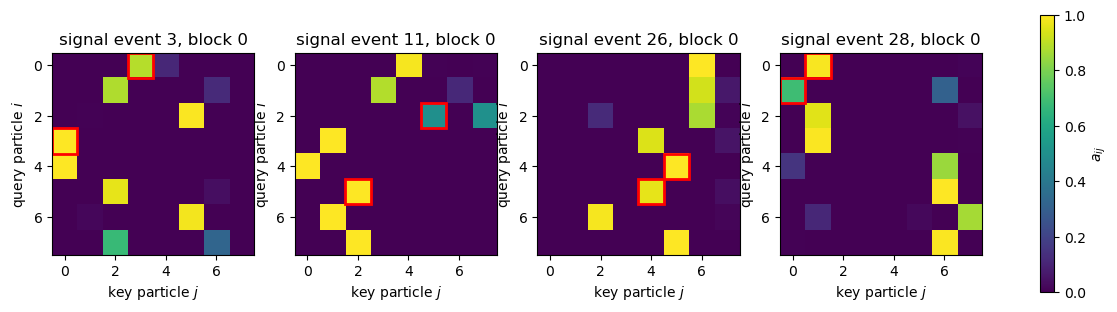

block 0: attention of a decay particle to its partner 0.94, to itself 0.00, uniform attention would be 0.12


In [10]:
with torch.no_grad():
    _, attention = transformer(x_test, return_attention=True)

########################################
### Choose the block here ###
block = 0
########################################

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, i in zip(axes, signal_events):
    im = ax.imshow(attention[block][i], cmap="viridis", vmin=0, vmax=1)
    a, b = pair_test[i].tolist()
    for (r, c) in [(a, b), (b, a)]:
        ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))
    ax.set_title(f"signal event {i.item()}, block {block}")
    ax.set_xlabel("key particle $j$")
    ax.set_ylabel("query particle $i$")
fig.colorbar(im, ax=axes, label="$a_{ij}$")
plt.show()

signal = y_test == 1
idx = torch.arange(signal.sum())
a_sig, pairs = attention[block][signal], pair_test[signal]
print(f"block {block}: attention of a decay particle to its partner {a_sig[idx, pairs[:, 0], pairs[:, 1]].mean():.2f}, "
      f"to itself {a_sig[idx, pairs[:, 0], pairs[:, 0]].mean():.2f}, uniform attention would be {1 / 8:.2f}")

**Solution notes:** in the first block the two decay particles attend almost exclusively to each other, although nobody told the network which particles form the pair. The scalar product $q_i \cdot k_j$ is exactly the right tool: back-to-back momenta have a large negative scalar product, which the learned matrices $W^Q$ and $W^K$ can turn into a large score. The other particles attend just as sharply, each to its most back-to-back partner, because the softmax always picks the best match. What distinguishes signal is how good the best match is, and that is what the following layers read off. The attention is the connecting tissue between the entries of the set. The second block works on the updated tokens and attends in a less interpretable way.

### Task 5: positional encoding and permutations
Our particles have no natural order, we shuffled them on purpose. Self-attention without positional encoding does not care about the order: permuting the input tokens only permutes the outputs, and the average over the tokens does not change.

**Task:** shuffle the particles of every test event with the same random permutation and check how much the classifier output changes, for our transformer and for a transformer trained with positional encoding. Which one would you use for particles, and which one for a time series?

In [11]:
torch.manual_seed(1)
transformer_pe = ParticleTransformer(use_pos_encoding=True)
train_classifier(transformer_pe, x_train, y_train, n_epochs=20)

perm = torch.randperm(8)
########################################
### Shuffle the particles here ###
x_shuffled = x_test[:, perm]
########################################

for model, name in [(transformer, "without positional encoding"), (transformer_pe, "with positional encoding")]:
    with torch.no_grad():
        change = (model(x_test) - model(x_shuffled)).abs().max().item()
    print(f"{name:28s}: accuracy {accuracy(model, x_test, y_test):.3f}, "
          f"largest change of C under shuffling {change:.2e}")

final loss 0.169
without positional encoding : accuracy 0.958, largest change of C under shuffling 1.94e-06


with positional encoding    : accuracy 0.952, largest change of C under shuffling 9.69e-01


**Solution notes:** without positional encoding the output changes only at the level of rounding errors: the transformer is exactly permutation invariant, which is the right symmetry for a set of particles. With positional encoding the network knows the position of each token in the list and its output changes under shuffling, although the position carries no physics here. For a sequence, like the time steps of a signal or the words of a sentence, the order *is* information, and there we need the positional encoding.

### Bonus: longer events
The transformer never assumed that an event has 8 particles: the matrices $W^{Q,K,V}$ act on single tokens, and attention works for any number of tokens.

**Bonus Task:** generate test events with 12 or 20 particles and evaluate the transformer trained on 8 particles, without retraining. Why can the dense network not even be evaluated? How does the accuracy change, and why?

In [12]:
for n_particles in [8, 12, 20]:
    x_long, y_long, _ = make_events(5000, n_particles=n_particles)
    print(f"{n_particles:2d} particles: transformer accuracy {accuracy(transformer, x_long, y_long):.3f}")

 8 particles: transformer accuracy 0.959
12 particles: transformer accuracy 0.923


20 particles: transformer accuracy 0.801


**Solution notes:** the dense network has a fixed input size of 24, so events with more particles do not fit. The transformer runs on any number of particles. Its accuracy drops somewhat for longer events, because there are more random particles which can accidentally look back-to-back, and because the average over more tokens dilutes the information from the pair; the network was never trained on this.